# Visualization of saved distance matrices


Visualize arrays saved in `\res` folder here.



In [137]:
import os
os.getcwd()

os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/')


In [2]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

from grid.grid_functions import *


incidence = True # If true, use incidence data instead of proportions.

In [3]:
# Load the files:
res_root = "grid/res/14_years/"
print(res_root + "dists_obs_14y_incidence.npy")
dists = np.load(res_root + "dists_obs_14y_incidence.npy")
pairs = np.load(res_root + "pairs_obs_14y_incidence.npy")


true_par1 = 0.0853#0.0758#0.145 # For real data, use mean point estimate
true_par2 = 0.058#0.013 #0.036

grid/res/14_years/dists_obs_14y_incidence.npy


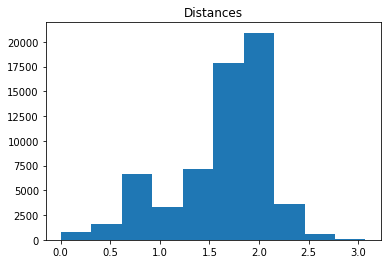

In [4]:
plt.hist(dists)
plt.title("Distances")
plt.show()

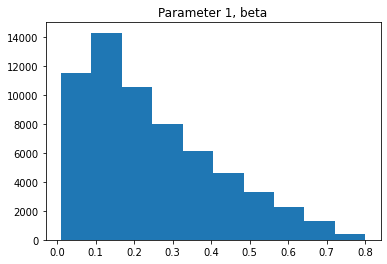

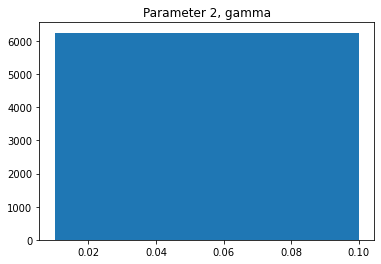

Overall mean of par1 (beta or net transmission) 0.24750027500000005
Overall mean of par2 (gamma or R) 0.05500000000000001


In [5]:
plt.hist(pairs[:,0])
plt.title("Parameter 1, beta") # or net transmission
plt.show()

plt.hist(pairs[:,1])
plt.title("Parameter 2, gamma") # or R
plt.show()

print("Overall mean of par1 (beta or net transmission)", np.mean(pairs[:,0]))
print("Overall mean of par2 (gamma or R)", np.mean(pairs[:,1]))

In [6]:
# Print point estimates:
eps = 0.4
print(f"Beta mean: {np.mean(pairs[np.where(dists< eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs[np.where(dists < eps)[0],0])/np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"True parameters (for synthetic data): beta = {true_par1}, gamma = {true_par2}")

Beta mean: 0.08525374936690398
Gamma mean: 0.05954265337210913
R = beta mean/gamma mean: 1.431809711839923
True parameters (for synthetic data): beta = 0.0853, gamma = 0.058


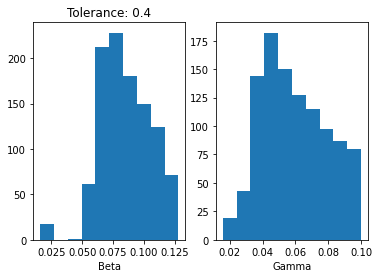

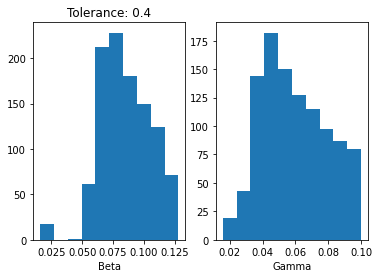

In [7]:
# Visualize:
plot_histograms(dists, pairs[:,0], pairs[:,1], eps, save = True, filename = res_root + "tolerance_hist_test.pdf")
plot_histograms(dists, pairs[:,0], pairs[:,1], eps, save = True, filename = res_root + "tolerance_hist_test.pdf")

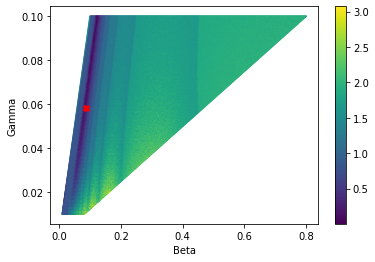

In [8]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_par1, true_gamma = true_par2,\
                        save = True, filename = res_root + "grid_scatter_test.pdf")

Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


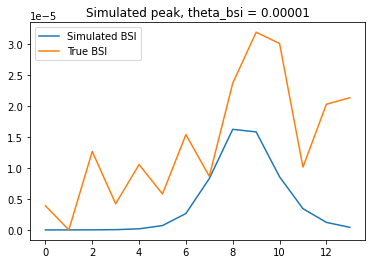

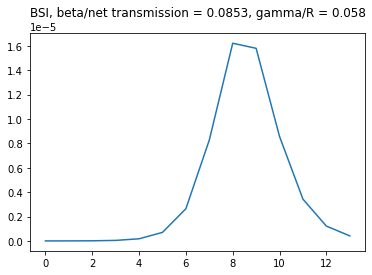

In [9]:
from cluster.scripts.load_data import *
n_weeks = 14*52
pop_size = 1000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.00001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if incidence: 
    bsi_obs_data = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = True, n_incidence_pop = pop_size)
else:
    if obs_data == "NORM":
        bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
    else:
        bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

plt.plot(bsi_real_sim[0], label = "Simulated BSI") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.
plt.plot(np.array(bsi_obs_data), label = "True BSI")
plt.legend()
plt.title("Simulated peak, theta_bsi = 0.00001")
plt.savefig(res_root + "incidence_results_scaled" + ".pdf", format="pdf", bbox_inches="tight")
plt.show()

plt.plot(bsi_real_sim[0])
plt.title(f"BSI, beta/net transmission = {true_par1}, gamma/R = {true_par2}")
plt.show()

### Aggregate example

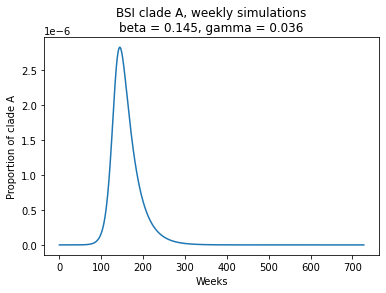

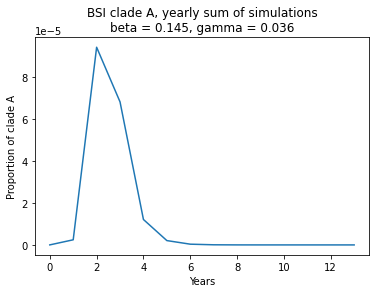

In [10]:
true_par1 = 0.145
true_par2 = 0.036



bsi_sim_agg = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)
bsi_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)



plt.plot(bsi_sim[0])
plt.title(f"BSI clade A, weekly simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Weeks")
plt.show()

plt.plot(bsi_sim_agg[0])
plt.title(f"BSI clade A, yearly sum of simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Years")
plt.show()

# Simulated aggregated data, visualizing colonisation

In [12]:
# Load the files:
#res_root = "/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/grid/res/16_years/" # or change working directory
print(res_root + "dists_synt_agg_14y_incidence.npy")
dists = np.load(res_root + "dists_synt_agg_14y_incidence.npy")
pairs = np.load(res_root + "pairs_synt_agg_14y_incidence.npy")


true_par1 = 0.145
true_par2 = 0.036 

grid/res/14_years/dists_synt_agg_14y_incidence.npy


In [13]:
# Simulator settings
from cluster.scripts.load_data import *

n_weeks = 16*52
pop_size = 5000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


0.01 0.01
0.8 0.1
0.0002811240963855443
[0.01, 0.04, 0.1]
[0.010000100000000001, 0.27333340000000006, 0.8]
(16,)
[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
16


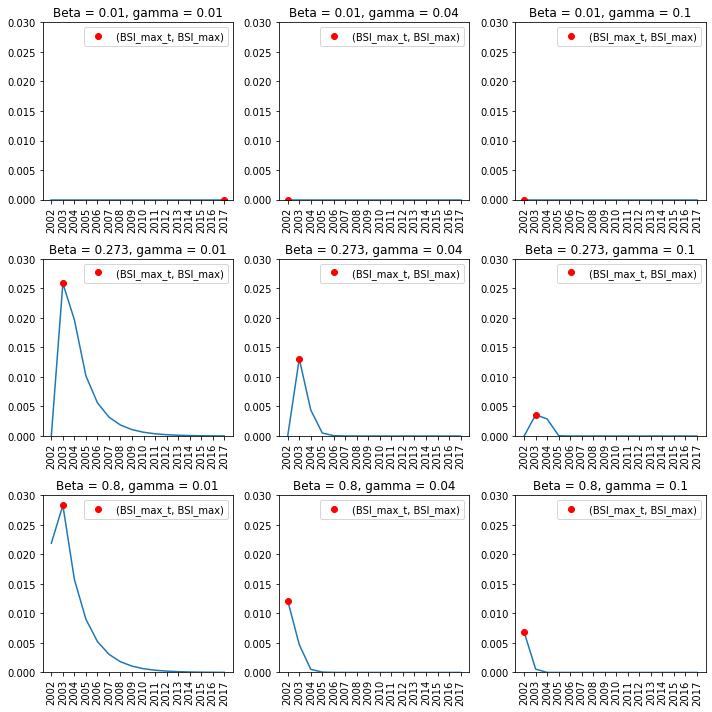

0.006813405720128996

In [20]:
# Alternative: evenly spaced parameter pairs
n = 3

inc = int(pairs.shape[0]/(n*n))

min_par1 = np.min(pairs[:,0])
min_par2 = np.min(pairs[:,1])

max_par1 = np.max(pairs[:,0])
max_par2 = np.max(pairs[:,1])

print(min_par2, min_par2)
print(max_par1, max_par2)

stepsize = pairs[3,0] - pairs[2,0]
print(stepsize)

# First, find 3 gamma values, evenly spaced:

gammas = [min(pairs[:,1]), min(pairs[:,1]) + (max(pairs[:,1]) - min(pairs[:,1]))/3, max(pairs[:,1])]
betas  = [min(pairs[:,0]), min(pairs[:,0]) + (max(pairs[:,0]) - min(pairs[:,0]))/3, max(pairs[:,0])]

print(gammas)
print(betas)

x = np.arange(0, 16)
y = []
par1s = []
par2s = []

for b in betas:
    for g in gammas:
        
        y.append(SIR_and_BSI_simulator(np.array([b]), np.array([g]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)[0])
        
        
        par1s.append(b)
        par2s.append(g)


        
print(y[1].shape)
# The following lines are a courtesy of ChatGPT :D
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

x_tick_labels = [i + 1 for i in range(2001, 2017)]
print(x_tick_labels)
print(len(x_tick_labels))

y_min = 0
y_max = 0.03

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot the line plots in each subplot
for i, ax in enumerate(axes):
    ax.plot(x, y[i])
    ax.set_title(f'Beta = {np.round(par1s[i],3)}, gamma = {np.round(par2s[i],4)}')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation = 90)
    
    point = ax.plot(BSI_max_t(y[i]), BSI_max(y[i]), "ro",label = "(BSI_max_t, BSI_max)")[0]
    ax.legend(handles = [point], loc='upper right')

# Adjust the spacing between subplots
plt.tight_layout()

# Display the grid of line plots
plt.show()

# Also show summaries
BSI_max(y[i])


# TODO: korjaa skaalaus

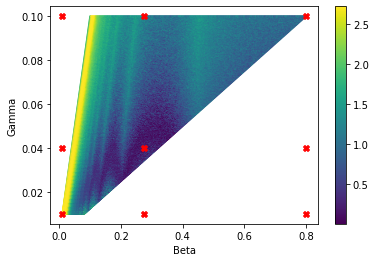

In [21]:
sc = plt.scatter(pairs[:,0], pairs[:,1], c = dists, s = 1)

for i in range(0, 9):
    plt.scatter(par1s[i], par2s[i], c= "red", marker = "X")
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.colorbar(sc)
sc.set_cmap('viridis') # 'plasma'
#sc.set_clim(cutoff_lower, cutoff_upper)

0
6944
13888
20832
27776
34720
41664
48608
55552
(16,)
[2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
16


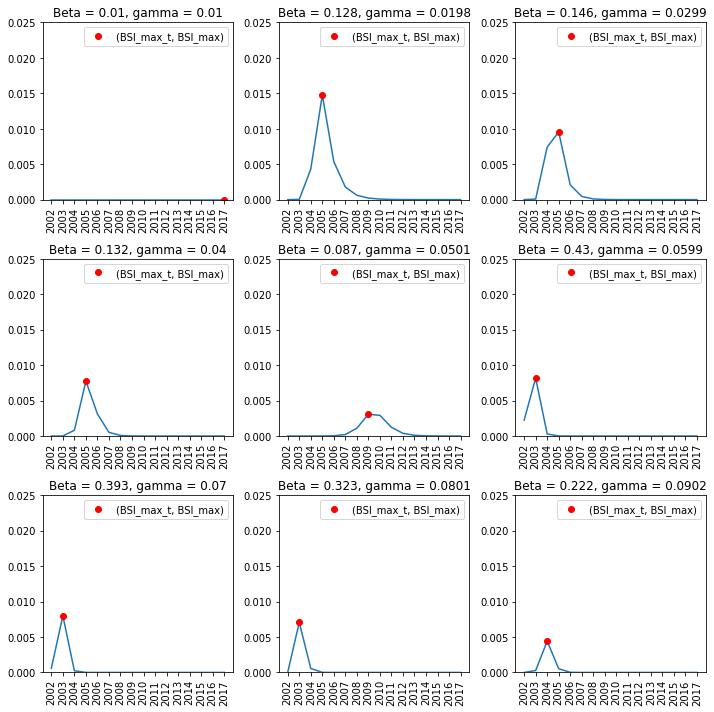

0.004408072290251554

In [22]:
# Form a 3x3 grid of colonisation figures

import matplotlib.pyplot as plt
import numpy as np

# Generate some random data for the line plots
#x = np.linspace(0, n_weeks, )
x = np.arange(0, 16)



# Find nine parameter pair examples & visualize them in a grid

y = []

n = 3

inc = int(pairs.shape[0]/(n*n))

par1s = []
par2s = []

for i in range(0,9):
    
    if i == 0:
        j = i
    else:
        j += inc
    
    if j > pairs.shape[0]:
        j = pairs.shape[0] - 1

    print(j)
        
    y.append(SIR_and_BSI_simulator(np.array([pairs[j,0]]), np.array([pairs[j,1]]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)[0])
    
    par1s.append(pairs[j,0])
    par2s.append(pairs[j,1])
    
    
print(y[1].shape)
# The following lines are (mostly) a courtesy of ChatGPT :D
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

x_tick_labels = [i + 1 for i in range(2001, 2017)]
print(x_tick_labels)
print(len(x_tick_labels))

y_min = 0
y_max = 0.025

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot the line plots in each subplot
for i, ax in enumerate(axes):
    ax.plot(x, y[i])
    ax.set_title(f'Beta = {np.round(par1s[i],3)}, gamma = {np.round(par2s[i],4)}')
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation = 90)
    
    point = ax.plot(BSI_max_t(y[i]), BSI_max(y[i]), "ro",label = "(BSI_max_t, BSI_max)")[0]
    ax.legend(handles = [point], loc='upper right')

# Adjust the spacing between subplots
plt.tight_layout()

# Display the grid of line plots
plt.show()

# Also show summaries
BSI_max(y[i])

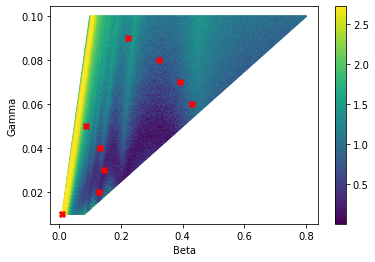

In [23]:
sc = plt.scatter(pairs[:,0], pairs[:,1], c = dists, s = 1)

for i in range(0, 9):
    plt.scatter(par1s[i], par2s[i], c= "red", marker = "X")
plt.xlabel("Beta")
plt.ylabel("Gamma")
plt.colorbar(sc)
sc.set_cmap('viridis') # 'plasma'
#sc.set_clim(cutoff_lower, cutoff_upper)

# Use incidence instead of proportions

TODO
- What, if anything, would change in the observational model?
    - Need to change the proportions to incidence in the col_to_bsi function. Colonisation also in terms of incidence per 1 000 000 population.
    - Do this on pen and paper first.
    - I think the only change necessary is to use counts instead of proportions with a population size of 1000000. Or proportions, but just change the population size.
- Load the data
- Fit in Triton.

In addtion
- Cutoff from 2005
    - Incidence data starts from 2004.

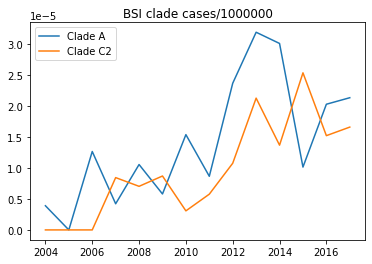

In [24]:
# Read incidence


csv_file = 'data/NORM_incidence.csv'
df = pd.read_csv(csv_file, delimiter=',')

df["A"]
df["Year"]

def get_incidence_data(csv_file, clade = "A", is_prop = True, n_incidence_pop = 1000000):
    # Get the BSI clade X incidence per 1000000 people.
    # If is_prop = True, divides the incidence by n_incidence_pop
    
    import pandas as pd

    csv_file = 'data/NORM_incidence.csv'
    df = pd.read_csv(csv_file, delimiter=',')
    
    rnames = df["Year"]
    
    df = df[clade]
    
    if is_prop:
        df = df/n_incidence_pop
     
    df.index = rnames
    
    return df

obs_data_A = get_incidence_data(csv_file, clade = "A", is_prop = True)
obs_data_C2 = get_incidence_data(csv_file, clade = "C2", is_prop = True)

# Plot the incidence data:

plt.plot(obs_data_A, label = "Clade A")
plt.plot(obs_data_C2, label = "Clade C2")
plt.title("BSI clade cases/1000000")
plt.legend()
plt.show()

In [25]:
df["Year"]

0     2004
1     2005
2     2006
3     2007
4     2008
5     2009
6     2010
7     2011
8     2012
9     2013
10    2014
11    2015
12    2016
13    2017
Name: Year, dtype: int64

# Find the number of BSI cases at the beginning

The data does not start at zero, at least not with clade A. Find the initial number of BSI cases to get $I_0$ and $S_0$ for the SIR model. $I_0$ is the number/proportion/incidence of colonized at the start of the study period.


"Backwards" observational model:

$$ \theta_{C,A} = \frac{\theta_{BSI,A}\theta_C}{\theta_{BSI,A} + \hat{OR}\theta_{BSI} - \theta_{BSI,A}\hat{OR}} $$

There is stochasticity in the chosen $I_0$ due to sampling $\hat{OR}$ from a normal distribution.


In [26]:
obs_data_A = get_incidence_data(csv_file, clade = "A", is_prop = True)
type(obs_data_A)

pandas.core.series.Series

In [27]:
theta_BSI_A_0 = obs_data_A.iloc[0]
theta_C = 1
theta_BSI = 0.00001
or_hat = 0.141 # pick a right value here.
    
I0 = theta_BSI_A_0*theta_C/(theta_BSI_A_0 + or_hat*theta_BSI - theta_BSI_A_0*or_hat)

In [62]:
7000/100000

0.07

/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
1
Using real data. Dataset: NORM, clade: A


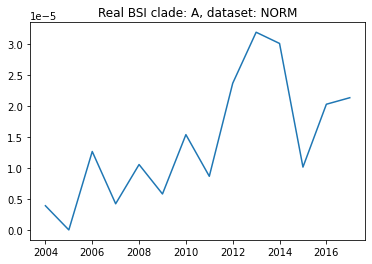

In [142]:
# Test this by fitting to real data:
print(os.getcwd())
import grid_params
importlib.reload(grid_params)
from grid_params import *

import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions) # for changes to take effect

use_incidence = True
is_prop = True
pop_size = 1000000
theta_bsi = 0.00001
res_id = "I0_test"
obs_data = "NORM"

print(batch_size)

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":theta_c, "theta_bsi":theta_bsi} # assume load_data loads or_data, norm_data and bsac_data
sim_pars = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":is_prop, "is_agg":is_agg,\
            "time_period":time_period, "reparam":reparam, "batch_size":batch_size, "random_state":random_state}



print(f"Using real data. Dataset: {obs_data}, clade: {clade}")

if use_incidence:
    bsi_obs = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = is_prop, n_incidence_pop = pop_size)
else:
    if obs_data == "NORM":
        bsi_obs = get_obs_BSI(df = norm_data, clade = clade, is_prop = is_prop)
    else:
        bsi_obs = get_obs_BSI(df = bsac_data, clade = clade, is_prop = is_prop)

plt.plot(bsi_obs)
plt.title(f"Real BSI clade: {clade}, dataset: {obs_data}")
plt.savefig(res_root + "real_BSI_obs_" + res_id + ".pdf", format="pdf", bbox_inches="tight")


In [143]:
dists, summary_dists = get_distance_points(pairs, bsi_obs, sim_pars, [BSI_max, BSI_max_t])

Iter: 0
I0 is 0.5846800703508966
I0 is 0.7199179544667391
I0 is 0.7342940178792706
I0 is 0.6146401292009922
I0 is 0.988199975069755
I0 is 0.5888045541358425
I0 is 0.49927994715667584
I0 is 0.6443635271286665
I0 is 0.6062461370801575
I0 is 0.5891251634583612
I0 is 0.5671725667642866
I0 is 0.8732151562690039
I0 is 0.7068522323699707
I0 is 0.5209984595348515
I0 is 0.7683256695017849
I0 is 0.9383771001418338
I0 is 0.5508198027991476
I0 is 0.7466700017922079
I0 is 0.6890392634830621
I0 is 0.5911745686318439
I0 is 1.1615420058565726
I0 is 0.6860824357205548
I0 is 0.5994242344575055
I0 is 0.46449591599980916
I0 is 0.6262227803051486
I0 is 1.0349068523909464
I0 is 0.6804203724326998
I0 is 0.819486138460209
I0 is 0.7321581973370197
I0 is 0.6033317602456018
I0 is 0.5533089866067866
I0 is 0.6089903477416342
I0 is 0.8592176633732859
I0 is 1.053030269411133
I0 is 0.8579972583708486
I0 is 0.6184143940944627
I0 is 0.834035421114677
I0 is 0.5944368012703279
I0 is 0.7267560253959472
I0 is 0.85369814158

KeyboardInterrupt: 

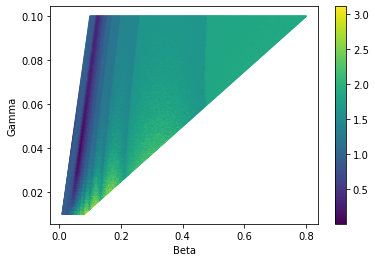

In [93]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_par1, true_gamma = true_par2,\
                        save = True, filename = res_root + "grid_scatter_test.pdf")

(array([11560., 14323., 10567.,  8035.,  6141.,  4603.,  3325.,  2240.,
         1278.,   428.]),
 array([0.0100001 , 0.08900009, 0.16800008, 0.24700007, 0.32600006,
        0.40500005, 0.48400004, 0.56300003, 0.64200002, 0.72100001,
        0.8       ]),
 <BarContainer object of 10 artists>)

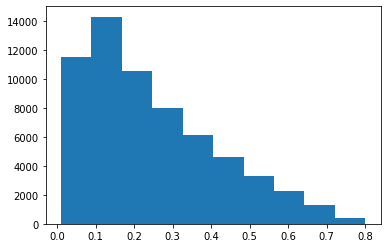

In [94]:
pairs[:,0]

plt.hist(pairs[:,0])

### Observations

Higher tolerance = different potential BSI lines. This makes sense, since the stricter the tolerance, the more restricted are the potential values for $\beta$ and $\gamma$.
- Actually, looking at random draws from the potential beta gamma values and the produced BSI curve could be a powerful tool in assessing what the tolerance should be. Test around, see that increasing epsilon increases the uncertainty about the simulated BSI curve!
- The mean BSI curve seems to fit the data well.



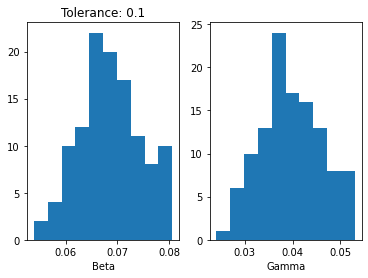

Beta mean: 0.0685700977192526
Gamma mean: 0.03967906107187371
R = beta mean/gamma mean: 1.7281179510534876
True parameters (for synthetic data): beta = None, gamma = None
0.010000100000000001
0.8
[0.06276897 0.06502669 0.07886581 0.06538957 0.06861167 0.06507362
 0.064312   0.07234424 0.0580614  0.06408121 0.06954842 0.0580614
 0.07281215 0.05773239 0.06548348 0.06934376 0.06798603 0.06276897
 0.07117425 0.07223732 0.07338698 0.06276897 0.06811281 0.07180567
 0.07062506 0.06308881 0.06456699 0.06673475 0.06761054 0.06473734
 0.0657399  0.07547778 0.06502669 0.06861167 0.06761054 0.06502669
 0.07001489 0.06177993 0.06338781 0.07057472 0.07409922 0.06688186
 0.06867407 0.07223732 0.06308881 0.06408121 0.06591121 0.06688186
 0.06373477 0.06065447 0.07913531 0.06654701 0.06548348 0.06883959
 0.07241052 0.06362539 0.07547778 0.06626638 0.0700299  0.06408121
 0.07242115 0.06610911 0.06934376 0.06801794 0.06362539 0.07547778
 0.07180567 0.06126702 0.06247669 0.06400381 0.05784512 0.07001489
 

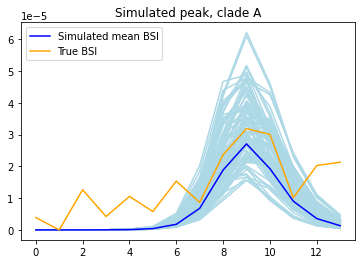

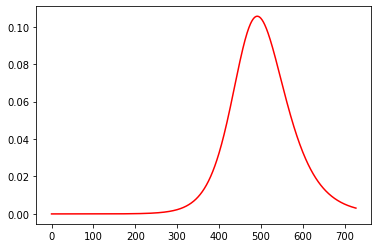

In [125]:
# Get the estimated beta and gamma parameters with some tolerance value:

bsi_obs_data = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = True, n_incidence_pop = pop_size)

# Print point estimates:
eps = 0.1

plot_histograms(dists, pairs[:,0], pairs[:,1], eps, save = False)

print(f"Beta mean: {np.mean(pairs[np.where(dists< eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs[np.where(dists < eps)[0],0])/np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"True parameters (for synthetic data): beta = {true_par1}, gamma = {true_par2}")

# Simulate based on the beta and gamma parameters - simulate more than one potential colonization to quantify uncertainty:

# The same indices, however, draws from a uniform distribution over the potential BSI curves (for example, from min(beta) to max(beta)),
# does not take into account the normal distribution of the parameters
acc_pairs = pairs[np.where(dists< eps)[0],:]
n_reps = 100
indx = np.random.choice(np.arange(1,len(acc_pairs[:,0])), size = n_reps) # pairs to choose from

par1s = acc_pairs[indx, 0]
par2s = acc_pairs[indx, 1]

print(par1s)

# random indices: these pairs are potentially not valid biologically:
#par1s = np.random.choice(pairs[np.where(dists< eps)[0],0], size = n_reps) #np.mean(pairs[np.where(dists< eps)[0],0])
#par2s = np.random.choice(pairs[np.where(dists < eps)[0],1], size = n_reps)

# In addition, show the mean simulation line:
mean_simseq = SIR_and_BSI_simulator(par1 = np.mean(pairs[np.where(dists< eps)[0],0]), par2 = np.mean(pairs[np.where(dists < eps)[0],1]), nt = sim_pars["n_weeks"], N = sim_pars["pop_size"],\
                               bsi_pars = bsi_pars, I0 = sim_pars["I0"], is_prop = sim_pars["is_prop"], is_agg = sim_pars["is_agg"],\
                               time_period = sim_pars["time_period"], reparam = sim_pars["reparam"], batch_size = sim_pars["batch_size"],\
                               random_state = sim_pars["random_state"])

for i in range(0,n_reps):
    simseq = SIR_and_BSI_simulator(par1 = par1s[i], par2 = par2s[i], nt = sim_pars["n_weeks"], N = sim_pars["pop_size"],\
                                   bsi_pars = bsi_pars, I0 = sim_pars["I0"], is_prop = sim_pars["is_prop"], is_agg = sim_pars["is_agg"],\
                                   time_period = sim_pars["time_period"], reparam = sim_pars["reparam"], batch_size = sim_pars["batch_size"],\
                                   random_state = sim_pars["random_state"])

    plt.plot(simseq[0], color = "lightblue") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.

plt.plot(mean_simseq[0], label = "Simulated mean BSI", color = "blue")
plt.plot(np.array(bsi_obs_data), label = "True BSI", color = "orange")


plt.legend()
plt.title(f"Simulated peak, clade {clade}")
plt.savefig(res_root + "incidence_results_I0_test" + ".pdf", format="pdf", bbox_inches="tight")
plt.show()

# also include the SIR curve representing the colonization proportion - mean value:
from cluster.scripts.SIR_functions import SIR, prop_to_nSIR
colseq = SIR(par1 = np.mean(pairs[np.where(dists< eps)[0],0]), par2 = np.mean(pairs[np.where(dists< eps)[0],1]),\
             nt = sim_pars["n_weeks"], N = sim_pars["pop_size"], I0 = sim_pars["I0"], reparam = sim_pars["reparam"],\
             batch_size = sim_pars["batch_size"], random_state = sim_pars["random_state"])

#print(colseq)
plt.plot(colseq[1][0], label = f"Mean colonization", color = "red")
plt.title(f"Colonization by clade {clade}")
plt.show()


Using real data. Dataset: NORM, clade: C1


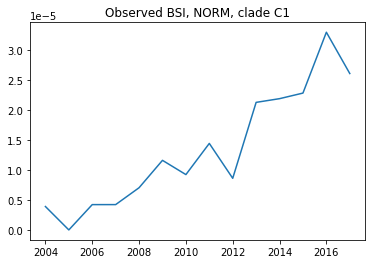

I0 is 2.355479858819919
Iter: 0
Iter: 1000
Iter: 2000
Iter: 3000
Iter: 4000
Iter: 5000
Iter: 6000
Iter: 7000
Iter: 8000
Iter: 9000
Iter: 10000
Iter: 11000
Iter: 12000
Iter: 13000
Iter: 14000
Iter: 15000
Iter: 16000
Iter: 17000
Iter: 18000
Iter: 19000
Iter: 20000
Iter: 21000
Iter: 22000
Iter: 23000
Iter: 24000
Iter: 25000
Iter: 26000
Iter: 27000
Iter: 28000
Iter: 29000
Iter: 30000
Iter: 31000
Iter: 32000
Iter: 33000
Iter: 34000
Iter: 35000
Iter: 36000
Iter: 37000
Iter: 38000
Iter: 39000
Iter: 40000
Iter: 41000
Iter: 42000
Iter: 43000
Iter: 44000
Iter: 45000
Iter: 46000
Iter: 47000
Iter: 48000
Iter: 49000
Iter: 50000
Iter: 51000
Iter: 52000
Iter: 53000
Iter: 54000
Iter: 55000
Iter: 56000
Iter: 57000
Iter: 58000
Iter: 59000
Iter: 60000
Iter: 61000
Iter: 62000


SyntaxError: 'return' outside function (<ipython-input-129-251afd96a047>, line 57)

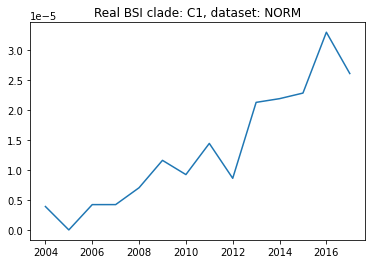

In [129]:
# Test nro 2: NORM, clade C1

import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions) # for changes to take effect

from cluster.scripts.load_data import * # load datasets

use_incidence = True
is_prop = True
pop_size = 1000000
theta_bsi = 0.00001
clade = "C1"
obs_data = "NORM"
theta_c = 1
is_agg = True
is_prop = True



bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":theta_c, "theta_bsi":theta_bsi} # assume load_data loads or_data, norm_data and bsac_data
sim_pars = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":is_prop, "is_agg":is_agg,\
            "time_period":time_period, "reparam":reparam, "batch_size":batch_size, "random_state":random_state}


print(f"Using real data. Dataset: {obs_data}, clade: {clade}")

if use_incidence:
    bsi_obs = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = is_prop, n_incidence_pop = pop_size)
    plt.plot(bsi_obs)
    plt.title(f"Observed BSI, {obs_data}, clade {clade}")
    plt.show()
else:
    if obs_data == "NORM":
        bsi_obs = get_obs_BSI(df = norm_data, clade = clade, is_prop = is_prop)
    else:
        bsi_obs = get_obs_BSI(df = bsac_data, clade = clade, is_prop = is_prop)

plt.plot(bsi_obs)
plt.title(f"Real BSI clade: {clade}, dataset: {obs_data}")
plt.savefig(res_root + "real_BSI_obs_" + res_id + ".pdf", format="pdf", bbox_inches="tight")

theta_bsi_a_0 = bsi_obs.iloc[0]/pop_size # note! Incidence data! Need to divide by the population size to get theta_bsi_a!


or_hat = get_OR_hat(bsi_pars["or_data"], clade = bsi_pars["clade"], dataset = bsi_pars["dataset"], batch_size = sim_pars["batch_size"], random_state = sim_pars["random_state"])[0]
I0 = (theta_bsi_a_0*bsi_pars["theta_c"]/(theta_bsi_a_0 + or_hat*bsi_pars["theta_bsi"] - theta_bsi_a_0*or_hat))*sim_pars["pop_size"] # this should be in individuals, not proportions!
print(f"I0 is {I0}")
sim_pars["I0"] = I0


dists, summary_dists = get_distance_points(pairs, bsi_obs, sim_pars, [BSI_max, BSI_max_t])






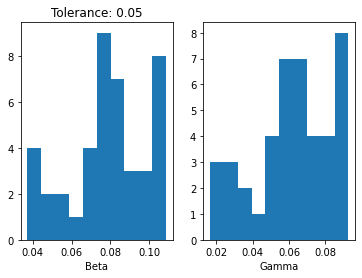

Beta mean: 0.07855698321861278
Gamma mean: 0.06184645558980107
R = beta mean/gamma mean: 1.2701937802166854
True parameters (for synthetic data): beta = None, gamma = None


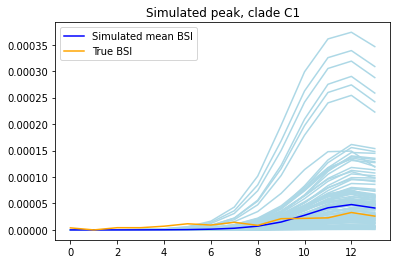

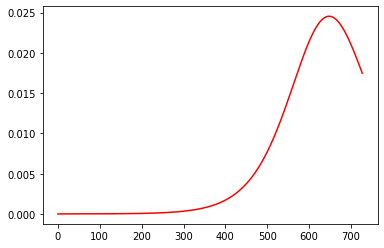

In [131]:
# Get the estimated beta and gamma parameters with some tolerance value:
eps = 0.05
bsi_obs_data = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = True, n_incidence_pop = 1000000)

# Print point estimates:

plot_histograms(dists, pairs[:,0], pairs[:,1], eps, save = False)

print(f"Beta mean: {np.mean(pairs[np.where(dists< eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs[np.where(dists < eps)[0],0])/np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"True parameters (for synthetic data): beta = {true_par1}, gamma = {true_par2}")

# Simulate based on the beta and gamma parameters - simulate more than one potential colonization to quantify uncertainty:

# The same indices, however, draws from a uniform distribution over the potential BSI curves (for example, from min(beta) to max(beta)),
# does not take into account the normal distribution of the parameters
acc_pairs = pairs[np.where(dists< eps)[0],:]
n_reps = 100
indx = np.random.choice(np.arange(1,len(acc_pairs[:,0])), size = n_reps) # pairs to choose from

par1s = acc_pairs[indx, 0]
par2s = acc_pairs[indx, 1]

# random indices: these pairs are potentially not valid biologically:
#par1s = np.random.choice(pairs[np.where(dists< eps)[0],0], size = n_reps) #np.mean(pairs[np.where(dists< eps)[0],0])
#par2s = np.random.choice(pairs[np.where(dists < eps)[0],1], size = n_reps)

# In addition, show the mean simulation line:
mean_simseq = SIR_and_BSI_simulator(par1 = np.mean(pairs[np.where(dists< eps)[0],0]), par2 = np.mean(pairs[np.where(dists < eps)[0],1]), nt = sim_pars["n_weeks"], N = sim_pars["pop_size"],\
                               bsi_pars = bsi_pars, I0 = sim_pars["I0"], is_prop = sim_pars["is_prop"], is_agg = sim_pars["is_agg"],\
                               time_period = sim_pars["time_period"], reparam = sim_pars["reparam"], batch_size = sim_pars["batch_size"],\
                               random_state = sim_pars["random_state"])

for i in range(0,n_reps):
    simseq = SIR_and_BSI_simulator(par1 = par1s[i], par2 = par2s[i], nt = sim_pars["n_weeks"], N = sim_pars["pop_size"],\
                                   bsi_pars = bsi_pars, I0 = sim_pars["I0"], is_prop = sim_pars["is_prop"], is_agg = sim_pars["is_agg"],\
                                   time_period = sim_pars["time_period"], reparam = sim_pars["reparam"], batch_size = sim_pars["batch_size"],\
                                   random_state = sim_pars["random_state"])

    plt.plot(simseq[0], color = "lightblue") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.

plt.plot(mean_simseq[0], label = "Simulated mean BSI", color = "blue")
plt.plot(np.array(bsi_obs_data), label = "True BSI", color = "orange")


plt.legend()
plt.title(f"Simulated peak, clade {clade}")
plt.savefig(res_root + "incidence_results_I0_test" + ".pdf", format="pdf", bbox_inches="tight")
plt.show()

# also include the SIR curve representing the colonization proportion - mean value:
from cluster.scripts.SIR_functions import SIR, prop_to_nSIR
colseq = SIR(par1 = np.mean(pairs[np.where(dists< eps)[0],0]), par2 = np.mean(pairs[np.where(dists< eps)[0],1]),\
             nt = sim_pars["n_weeks"], N = sim_pars["pop_size"], I0 = sim_pars["I0"], reparam = sim_pars["reparam"],\
             batch_size = sim_pars["batch_size"], random_state = sim_pars["random_state"])

#print(colseq)
plt.plot(colseq[1][0], label = f"Mean colonization", color = "red")
plt.show()


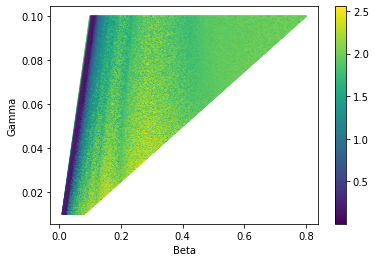

In [134]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_par1, true_gamma = true_par2,\
                        save = False, filename = res_root + "grid_scatter_test.pdf", cutoff_upper = 0.5, cutoff_lower = 0)

TODO: 
- Käytä mediaania
- C0 simulaation sisällä - miksi lähtee nollasta?
- Resoluutio